In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Winsorizer
!pip install feature_engine --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.4 MB/s eta 0:00:00a 0:00:01


In [1]:
import numpy as np
import pandas as pd
import os
from feature_engine.outliers import Winsorizer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2, RFE, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import pickle
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# df = pd.read_csv("/kaggle/input/us-drought-meteorological-data/train_timeseries/train_timeseries.csv")

df_unshuffled = pd.read_csv("/content/drive/MyDrive/152 Dataset/train_timeseries.csv")
shuffled_df = df_unshuffled.sample(frac=1).reset_index(drop=True)
shuffled_df.head(5000).to_csv('train.csv', index=False)

df = pd.read_csv("train.csv")
df.head()

,fips,date,PRECTOT,PS,QV2M,T2M,T2MDEW,T2MWET,T2M_MAX,T2M_MIN,...,TS,WS10M,WS10M_MAX,WS10M_MIN,WS10M_RANGE,WS50M,WS50M_MAX,WS50M_MIN,WS50M_RANGE,score
0,55111,2000-05-29,0.03,98.10,7.94,14.08,10.11,10.11,19.15,7.20,...,14.23,2.66,4.89,0.20,4.70,3.88,8.25,0.26,7.99,NaN
1,19051,2001-09-09,6.62,98.71,8.14,16.55,10.67,10.67,22.04,12.57,...,16.92,3.87,6.00,2.29,3.71,5.68,7.49,4.28,3.21,NaN
2,55027,2002-10-22,0.29,99.23,3.89,2.83,0.14,0.15,8.46,-1.54,...,3.60,4.98,6.03,4.16,1.88,6.30,8.03,5.03,3.00,0.0
3,38095,2000-06-21,3.88,94.35,8.76,16.47,11.13,11.13,21.50,12.57,...,16.57,10.46,13.31,4.14,9.18,14.30,17.16,8.36,8.79,NaN
4,13227,2014-04-20,0.00,97.66,7.16,13.70,8.53,8.53,22.03,6.70,...,13.69,2.24,3.58,1.45,2.13,4.54,6.02,2.16,3.86,NaN


In [4]:
df["score"].value_counts()
display(df.info())
display(df.size)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   fips         5000 non-null   int64  
 1   date         5000 non-null   object 
 2   PRECTOT      5000 non-null   float64
 3   PS           5000 non-null   float64
 4   QV2M         5000 non-null   float64
 5   T2M          5000 non-null   float64
 6   T2MDEW       5000 non-null   float64
 7   T2MWET       5000 non-null   float64
 8   T2M_MAX      5000 non-null   float64
 9   T2M_MIN      5000 non-null   float64
 10  T2M_RANGE    5000 non-null   float64
 11  TS           5000 non-null   float64
 12  WS10M        5000 non-null   float64
 13  WS10M_MAX    5000 non-null   float64
 14  WS10M_MIN    5000 non-null   float64
 15  WS10M_RANGE  5000 non-null   float64
 16  WS50M        5000 non-null   float64
 17  WS50M_MAX    5000 non-null   float64
 18  WS50M_MIN    5000 non-null   float64
 19  WS50M_

None

105000

In [5]:
#data cleaning and standardization
df.isnull().sum()
df.dropna(inplace=True)

df['year'] = pd.DatetimeIndex(df['date']).year
df['month'] = pd.DatetimeIndex(df['date']).month
df['day'] = pd.DatetimeIndex(df['date']).day
df['score'] = df['score'].round().astype(int)
df.dtypes

,0
fips,int64
date,object
PRECTOT,float64
PS,float64
QV2M,float64
T2M,float64
T2MDEW,float64
T2MWET,float64
T2M_MAX,float64
T2M_MIN,float64


In [6]:
print("df has missing values:", df.isnull().any().any())

df has missing values: False


In [7]:
# We can re-run the value counts to see the rounded scores' counts
df["score"].value_counts()

,count
score,
0,421
1,116
2,82
3,50
4,26
5,13


In [8]:
# Check for duplicates
duplicates = df.duplicated().any()
print(f"Does the DataFrame have duplicated rows? {duplicates}")

Does the DataFrame have duplicated rows? False


In [9]:
# For numeric columns
display(df.describe().T)

# For Categorical columns
display(df.describe(include=['object']))

,count,mean,std,min,25%,50%,75%,max
fips,708.0,31176.737288,14936.974611,1023.00,19070.5000,31056.000,45072.0000,56037.00
PRECTOT,708.0,2.219689,5.059383,0.00,0.0000,0.115,1.6900,38.31
PS,708.0,96.541992,5.560658,70.34,95.7475,98.360,99.8350,102.86
QV2M,708.0,7.742740,4.784686,0.54,3.7600,6.375,11.3100,19.65
T2M,708.0,12.934322,11.016148,-21.43,4.1900,13.955,22.3600,34.03
T2MDEW,708.0,6.749322,10.178655,-22.41,-1.1425,6.770,15.5425,25.00
T2MWET,708.0,6.784266,10.131194,-22.20,-1.0200,6.770,15.5425,25.00
T2M_MAX,708.0,18.959619,11.666785,-15.88,10.4175,21.185,28.6075,40.74
T2M_MIN,708.0,7.475819,10.630644,-27.27,-0.7475,7.625,16.2850,28.74
T2M_RANGE,708.0,11.483729,4.322364,1.67,8.3250,11.415,14.5650,23.96


,date
count,708
unique,484
top,2005-07-05
freq,5


In [10]:
cols = list(df.columns)
cols

['fips',
 'date',
 'PRECTOT',
 'PS',
 'QV2M',
 'T2M',
 'T2MDEW',
 'T2MWET',
 'T2M_MAX',
 'T2M_MIN',
 'T2M_RANGE',
 'TS',
 'WS10M',
 'WS10M_MAX',
 'WS10M_MIN',
 'WS10M_RANGE',
 'WS50M',
 'WS50M_MAX',
 'WS50M_MIN',
 'WS50M_RANGE',
 'score',
 'year',
 'month',
 'day']

In [11]:
#Get numeric features out into a list and remove unnecessary features
measures_list = [x for x in df.select_dtypes(include=["int64", "float64", "int32"])]
remove_list = ["fips", "score", "year", "month", "day"]

# List comprehension for applying remove_list to our measures_list
measures_list = [i for i in measures_list if i not in remove_list]
# Create measures_df out of df with only the numeric features we want to visualize
measures_df = df[measures_list]

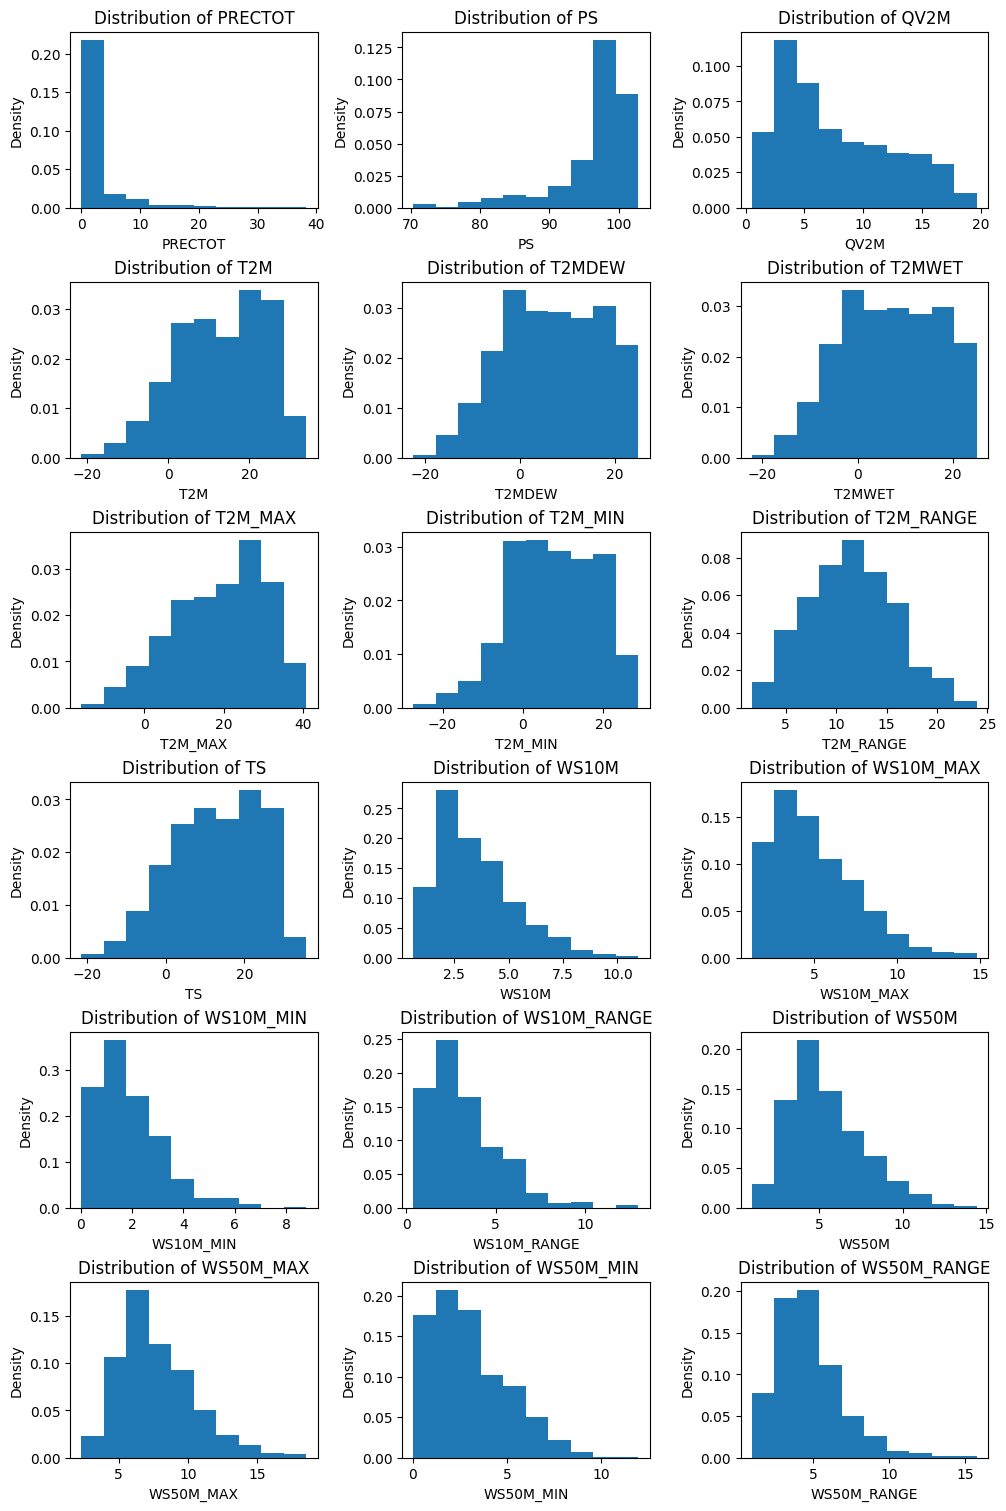

In [12]:
num_cols = 3  # Number of histograms per figure
num_rows = (len(measures_list) + num_cols - 1) // num_cols  # Calculate number of rows needed

# Create a figure with subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 15), constrained_layout=True)

# Flatten the axes array for easier iteration
axes = axes.flatten()

for i, col_name in enumerate(measures_list):
    ax = axes[i]
    ax.hist(measures_df[col_name], density=True)
    ax.set_xlabel(col_name)
    ax.set_ylabel('Density')
    ax.set_title(f'Distribution of {col_name}')

# Turn off axes for any unused subplots
for j in range(len(measures_list), len(axes)):
    axes[j].axis('off')

plt.show()

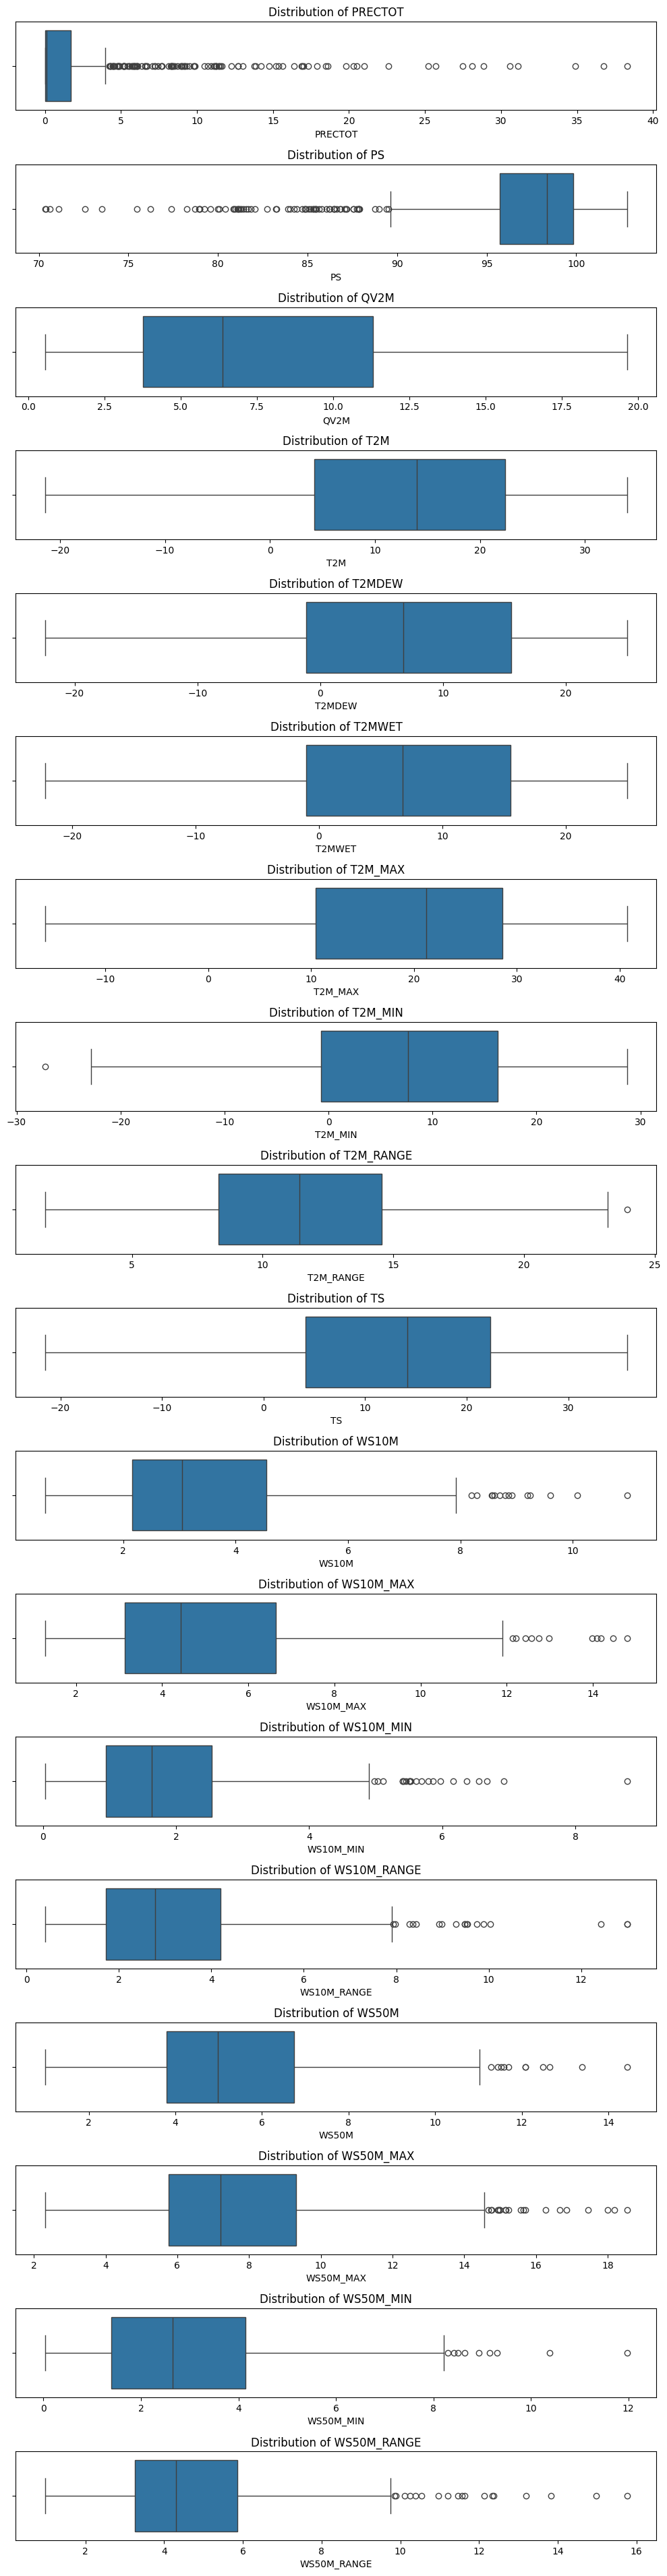

In [13]:
plt.figure(figsize=(10,40))
for x in (range(1,19)):
    plt.subplot(19,1,x)
    sns.boxplot(x =  measures_df.columns[x-1], data=measures_df)
    x_name = measures_df.columns[x-1]
    plt.title(f'Distribution of {x_name}')
plt.tight_layout()

In [14]:
outlier = Winsorizer(capping_method="gaussian",
                     tail="both",
                    fold=3,
                    variables = measures_list,
                    missing_values="ignore")

outlier.fit(df)

Winsorizer(fold=3, missing_values='ignore', tail='both',
           variables=['PRECTOT', 'PS', 'QV2M', 'T2M', 'T2MDEW', 'T2MWET',
                      'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'TS', 'WS10M',
                      'WS10M_MAX', 'WS10M_MIN', 'WS10M_RANGE', 'WS50M',
                      'WS50M_MAX', 'WS50M_MIN', 'WS50M_RANGE'])

In [15]:
# What are our new min and max values?
outlier.right_tail_caps_

{'PRECTOT': 17.387116116080307,
 'PS': 113.2121793523738,
 'QV2M': 22.08665635903695,
 'T2M': 45.959417071145225,
 'T2MDEW': 37.26371418033712,
 'T2MWET': 37.156374588955046,
 'T2M_MAX': 53.9352459322178,
 'T2M_MIN': 39.34521934024347,
 'T2M_RANGE': 24.441660791106173,
 'TS': 46.63946607214897,
 'WS10M': 8.846935996296384,
 'WS10M_MAX': 12.767275650566946,
 'WS10M_MIN': 5.719420506852406,
 'WS10M_RANGE': 8.994551185366674,
 'WS50M': 12.18852064718133,
 'WS50M_MAX': 16.02474514527372,
 'WS50M_MIN': 9.144067251804682,
 'WS50M_RANGE': 11.176545392271077}

In [16]:
outlier.left_tail_caps_

{'PRECTOT': -12.947737585006863,
 'PS': 79.87180369847366,
 'QV2M': -6.60117613304825,
 'T2M': -20.090773003348616,
 'T2MDEW': -23.765070112540503,
 'T2MWET': -23.58784351550872,
 'T2M_MAX': -16.016008644082213,
 'T2M_MIN': -24.39358092216437,
 'T2M_RANGE': -1.4742031639875304,
 'TS': -20.713872851809988,
 'WS10M': -1.880580064092995,
 'WS10M_MAX': -2.598688079945477,
 'WS10M_MIN': -1.9674713543100326,
 'WS10M_RANGE': -2.5788167220898397,
 'WS50M': -1.334735336446867,
 'WS50M_MAX': -0.5620332808669408,
 'WS50M_MIN': -3.135338438245358,
 'WS50M_RANGE': -1.7233250532880255}

In [17]:
# Apply the Winsorizer to our main DataFrame
df = outlier.transform(df)

In [18]:
# Create a new categorical DataFrame for visualization
categorical_column_list = ['score','year','month','day']
df_categorical = df[['score','year','month','day']]

<Figure size 1000x4000 with 0 Axes>

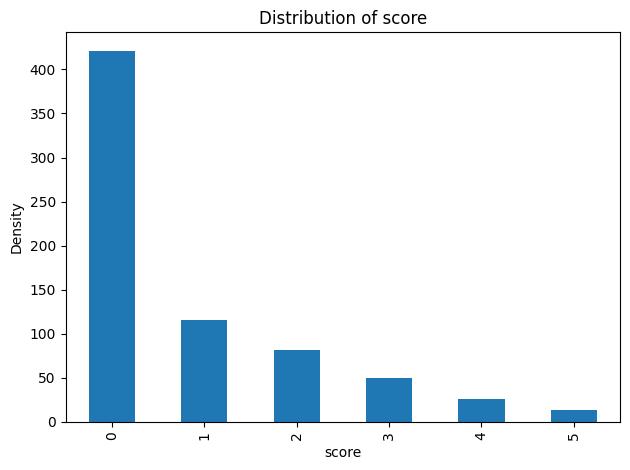

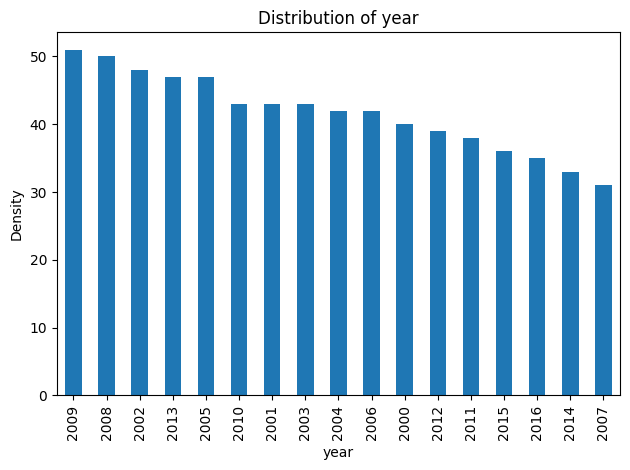

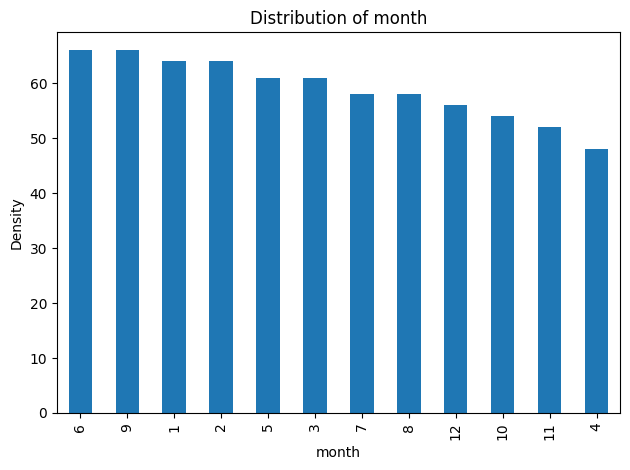

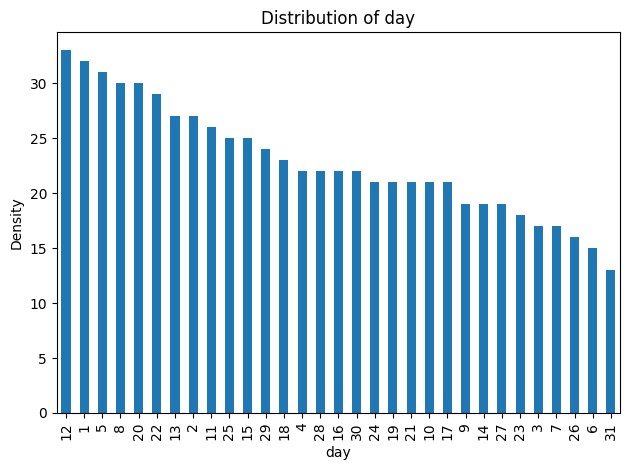

In [19]:
plt.figure(figsize=(10,40))
for col_name in categorical_column_list:
    plt.figure()
    df_categorical[col_name].value_counts().plot(kind = 'bar')
    x_name = col_name
    y_name = 'Density'
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.title('Distribution of {x_name}'.format(x_name=x_name))
    plt.tight_layout()

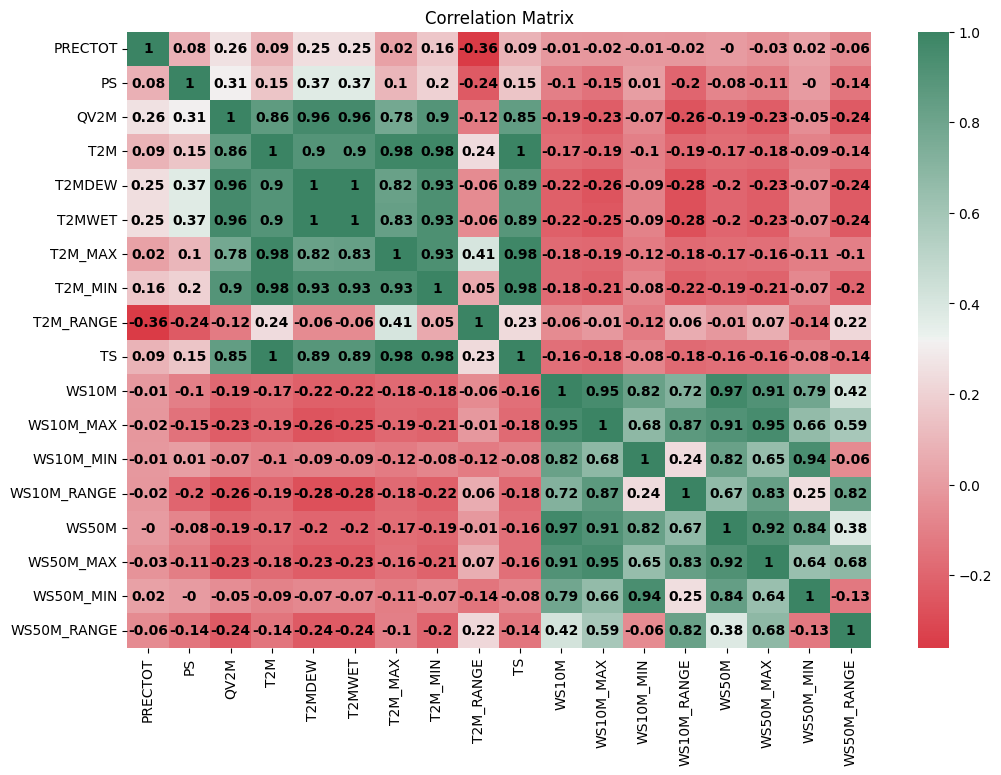

In [20]:
# Get .corr and visualize with Seaborn for an easier visual analysis of our features
correlation_matrix = measures_df.corr().round(2)

plt.figure(figsize=(12,8))
sns.heatmap(data=correlation_matrix, annot=True, annot_kws={"size": 10, "weight": "bold", "color": "black"}, cmap=sns.diverging_palette(10, 150, as_cmap=True))
plt.title("Correlation Matrix")
plt.show()

In [21]:
# We make sure our column names and values are in a single form. In this case there're no string values
df.columns = df.columns.str.lower().str.replace(" ","_")
df.head()

,fips,date,prectot,ps,qv2m,t2m,t2mdew,t2mwet,t2m_max,t2m_min,...,ws10m_min,ws10m_range,ws50m,ws50m_max,ws50m_min,ws50m_range,score,year,month,day
2,55027,2002-10-22,0.29,99.23,3.89,2.83,0.14,0.15,8.46,-1.54,...,4.16,1.88,6.30,8.03,5.03,3.00,0,2002,10,22
15,39079,2015-10-20,0.00,99.42,4.71,12.44,2.80,2.83,22.57,6.23,...,2.13,1.41,5.09,6.03,3.46,2.56,0,2015,10,20
18,1029,2006-03-28,1.10,99.02,7.57,11.32,9.50,9.50,16.66,7.76,...,1.53,1.63,4.80,5.55,3.73,1.83,0,2006,3,28
22,39135,2005-10-04,0.00,98.87,10.52,20.36,14.56,14.57,27.45,15.00,...,1.62,1.52,4.07,6.14,1.77,4.36,0,2005,10,4
54,13033,2009-06-30,0.00,99.22,10.96,27.39,15.20,15.20,35.60,19.53,...,2.00,3.04,5.53,7.03,2.40,4.62,0,2009,6,30


In [22]:
# Drop useless columns | remove fips and date
df = df.drop(columns=["date", "fips"])

# X, y
X = df.drop(["score"], axis=1)
y = df["score"]

# Get shapes of our variables and targets
print("X.shape: {} \ny.shape: {}".format(X.shape, y.shape))

X.shape: (708, 21) 
y.shape: (708,)


In [23]:
# Split our data for train and test sets for validation, test size is 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)